# 03 — Per-strategy coefficient fingerprints

Notebook 02 settled on a robust hinge model with the Δs target:

$$\Delta s_t \;=\; \beta_+ (m_t - v)_+ \;-\; \beta_- (v - m_t)_+ \;+\; \gamma_s s_{t-1} \;+\; \gamma_m m_{t-1} \;+\; \delta_+ \Delta s_{t-1,+} \;-\; \delta_- \Delta s_{t-1,-} \;+\; \alpha_0$$

The **shape** of this model is the same across seller strategies — that's a consequence of the functional-form hypothesis. The **coefficients** should differ, and those differences should encode what the strategy actually is. This notebook:

1. Fits the robust hinge model **independently per seller strategy** (6 fits on the fixed×fixed sweeps nb1–nb6).
2. Visualizes each strategy's coefficient fingerprint with bootstrap CIs.
3. Tests whether these fingerprints are statistically separable (pairwise CI overlap, and a classifier built on the coefficients).
4. Shows that the six strategies live in a low-dimensional space that the key hinge parameters `(β_+, β_-)` already capture.

This gets directly at the policy-learning question: *does each strategy induce a distinct decision function in `(m_t, v, s_{t-1})` space?*

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from analysis_common import (
    load_all_runs, add_hinge_features, NEGOTIATION_MASK,
    SELLER_STRATEGIES, setup_plot_defaults,
)
setup_plot_defaults()

# Restrict to the fixed×fixed notebooks so every seller strategy is stationary
# within a run; this is where per-strategy fingerprints make sense.
df_all = load_all_runs('results_0416b',
                        notebooks=['nb1', 'nb2', 'nb3', 'nb4', 'nb5', 'nb6'])
df_all = add_hinge_features(df_all)
sub_all = df_all[NEGOTIATION_MASK(df_all) & (df_all['round_t'] <= 8)].copy()
sub_all = sub_all.dropna(subset=['s_prev2', 'ds_prev'])
print(f'{len(sub_all):,} Negotiation-region transitions across '
      f'{sub_all["run_idx"].nunique()} runs.')
print(sub_all['supplier_active_strategy_curr'].value_counts().to_frame('n_rows'))

[analysis_common] discovered 60 condition files under results_0416b
[analysis_common] built 18274 transition rows from 1320 unique runs
7,843 Negotiation-region transitions across 1320 runs.
                               n_rows
supplier_active_strategy_curr        
boulware_seller                  1319
relational                       1318
anchor_high                      1317
cooperative                      1307
conceder_seller                  1306
tit_for_tat_matcher              1276


## 1. Per-strategy robust fit

For each of the six strategies we:
- filter to rows where `supplier_active_strategy_curr == strategy`,
- fit a Ridge with cross-validated α on standardized features,
- produce grouped-bootstrap 95% CIs,
- measure held-out R² on a run-level split.

In [2]:
FEATURES = ['diff_pos', 'diff_neg', 's_prev', 'm_prev', 'ds_pos', 'ds_neg']

def extract_scaled_coefs(pipe, feature_names):
    sc = pipe.named_steps['sc']
    m = pipe.named_steps['m']
    return pd.Series(np.asarray(m.coef_).flatten() / sc.scale_,
                      index=feature_names)

def fit_strategy(df_s, n_boot=150, test_size=0.3, rng_seed=0):
    """Fit Ridge on Δs target for one strategy; return coefs, CIs, held-out R²."""
    X = df_s[FEATURES].values
    y = df_s['delta_s'].values
    g = df_s['run_idx'].values

    # Held-out run-level split
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=rng_seed)
    tr, te = next(gss.split(X, y, g))

    pipe = Pipeline([('sc', StandardScaler()),
                      ('m', RidgeCV(alphas=np.logspace(-3, 3, 40)))])
    pipe.fit(X[tr], y[tr])
    point = extract_scaled_coefs(pipe, FEATURES)
    y_pred = pipe.predict(X[te])
    r2 = r2_score(y[te], y_pred)
    rmse = np.sqrt(mean_squared_error(y[te], y_pred))

    # Grouped bootstrap over training runs
    rng = np.random.default_rng(rng_seed)
    tr_runs = np.unique(g[tr])
    boot = np.zeros((n_boot, len(FEATURES)))
    for b in range(n_boot):
        sampled = rng.choice(tr_runs, size=len(tr_runs), replace=True)
        idxs = np.concatenate([np.where(g == r)[0] for r in sampled])
        p = Pipeline([('sc', StandardScaler()),
                       ('m', RidgeCV(alphas=np.logspace(-3, 3, 40)))])
        p.fit(X[idxs], y[idxs])
        boot[b] = extract_scaled_coefs(p, FEATURES).values
    ci_lo = np.quantile(boot, 0.025, axis=0)
    ci_hi = np.quantile(boot, 0.975, axis=0)
    return {
        'point':   point.values,
        'ci_lo':   ci_lo,
        'ci_hi':   ci_hi,
        'boot':    boot,
        'r2_held': r2,
        'rmse_held': rmse,
        'n_rows':  len(df_s),
        'n_runs':  len(np.unique(g)),
    }

per_strat = {}
present = sorted(sub_all['supplier_active_strategy_curr'].dropna().unique(),
                  key=lambda s: SELLER_STRATEGIES.index(s) if s in SELLER_STRATEGIES else 99)
for strat in present:
    sub = sub_all[sub_all['supplier_active_strategy_curr'] == strat]
    if len(sub) < 30 or sub['run_idx'].nunique() < 4:
        print(f'  skipping {strat}: only {len(sub)} rows / {sub["run_idx"].nunique()} runs (too sparse for a stable fit)')
        continue
    per_strat[strat] = fit_strategy(sub, n_boot=150, rng_seed=0)
    print(f'  fitted {strat}: '
          f'R²={per_strat[strat]["r2_held"]:.3f}, '
          f'RMSE={per_strat[strat]["rmse_held"]:.3f}, '
          f'n={per_strat[strat]["n_rows"]}')
if not per_strat:
    raise RuntimeError('No strategy has enough data.  Either the results_0416b/ '
                       'tree is empty or the per-strategy guard is too strict.')

  fitted anchor_high: R²=0.707, RMSE=0.057, n=1317
  fitted cooperative: R²=0.667, RMSE=0.252, n=1307
  fitted boulware_seller: R²=0.545, RMSE=0.027, n=1319
  fitted conceder_seller: R²=0.463, RMSE=0.268, n=1306
  fitted tit_for_tat_matcher: R²=-0.013, RMSE=0.506, n=1276
  fitted relational: R²=0.272, RMSE=0.559, n=1318


## 2. Coefficient fingerprint table

In [3]:
rows = []
for strat, res in per_strat.items():
    for j, feat in enumerate(FEATURES):
        rows.append({
            'strategy': strat, 'feature': feat,
            'coef':   res['point'][j],
            'ci_lo':  res['ci_lo'][j],
            'ci_hi':  res['ci_hi'][j],
            'width':  res['ci_hi'][j] - res['ci_lo'][j],
        })
fp_long = pd.DataFrame(rows)
fp_wide = fp_long.pivot(index='feature', columns='strategy', values='coef').round(3)
display(fp_wide[list(per_strat.keys())])

summary = pd.DataFrame({
    'strategy': list(per_strat.keys()),
    'held_R2':  [per_strat[s]['r2_held']   for s in per_strat],
    'RMSE':     [per_strat[s]['rmse_held'] for s in per_strat],
    'n_rows':   [per_strat[s]['n_rows']    for s in per_strat],
    'n_runs':   [per_strat[s]['n_runs']    for s in per_strat],
}).round(3)
print('\nPer-strategy held-out R² (on Δs):')
display(summary)

strategy,anchor_high,cooperative,boulware_seller,conceder_seller,tit_for_tat_matcher,relational
feature,,,,,,
diff_neg,-0.000,0.040,0.000,0.010,0.204,0.002
diff_pos,-0.000,0.104,0.001,0.165,-0.208,-0.003
ds_neg,-0.482,-0.387,-0.443,-0.372,-0.043,-0.154
ds_pos,0.048,0.080,0.078,-0.011,-0.027,0.012
m_prev,0.002,0.031,-0.000,-0.005,0.153,-0.010
s_prev,-0.002,-0.046,-0.000,-0.013,-0.138,-0.004



Per-strategy held-out R² (on Δs):


,strategy,held_R2,RMSE,n_rows,n_runs
0,anchor_high,0.707,0.057,1317,220
1,cooperative,0.667,0.252,1307,220
2,boulware_seller,0.545,0.027,1319,220
3,conceder_seller,0.463,0.268,1306,220
4,tit_for_tat_matcher,-0.013,0.506,1276,220
5,relational,0.272,0.559,1318,220


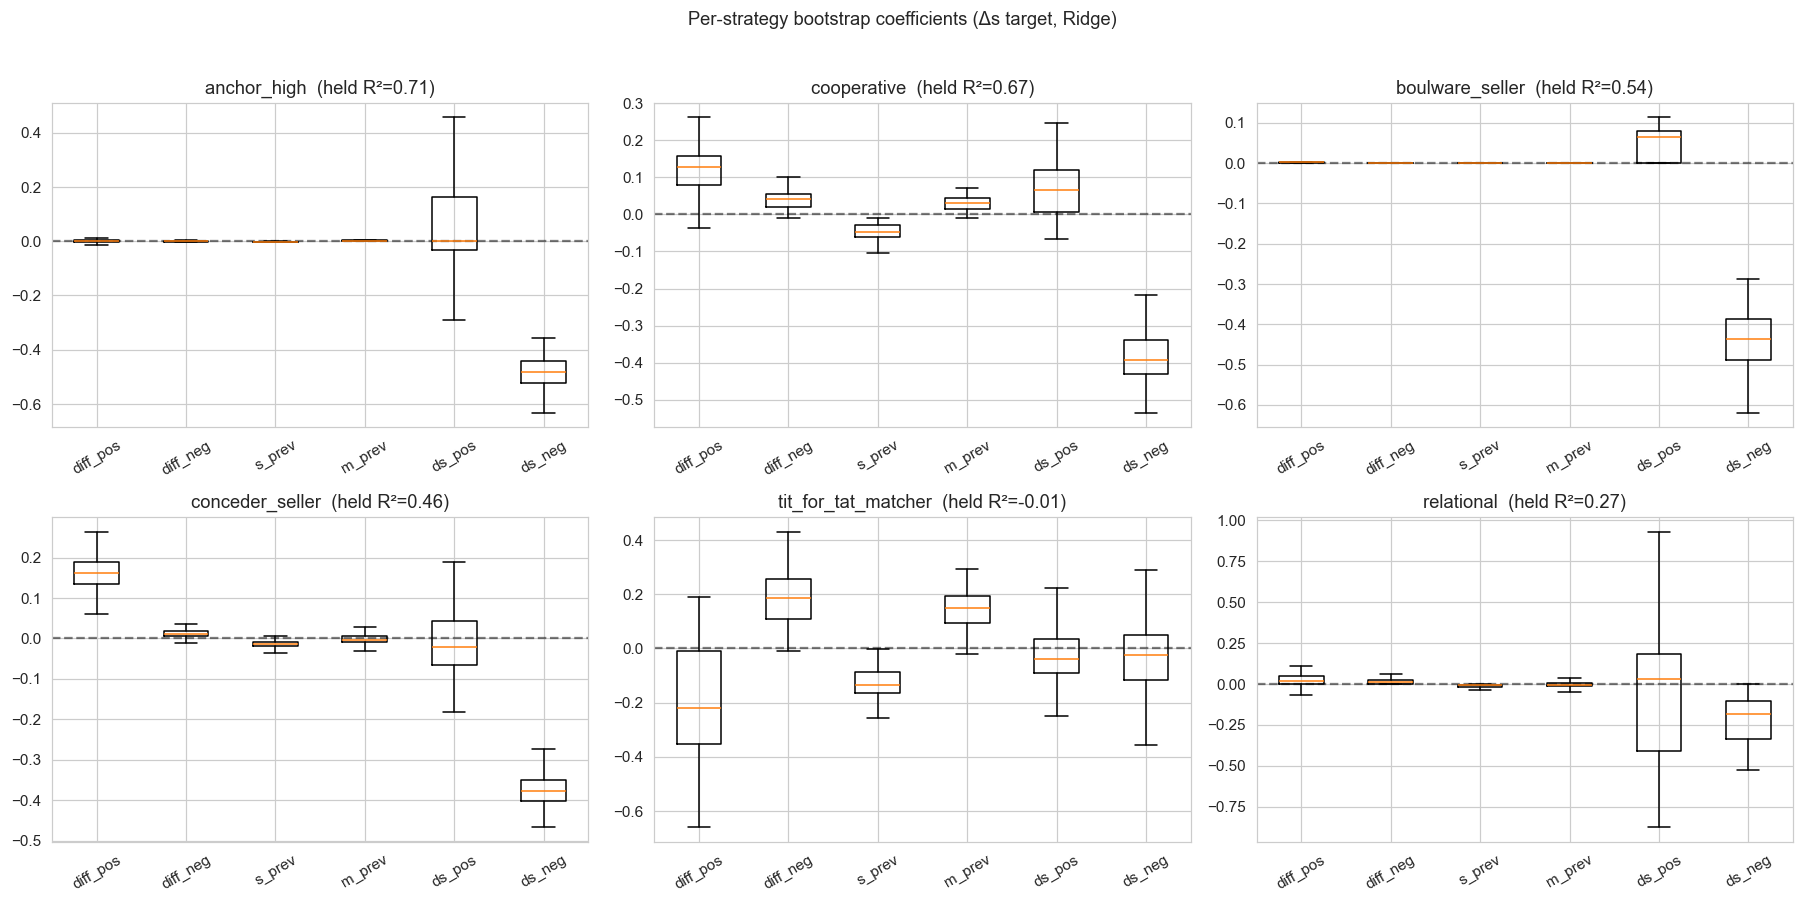

In [4]:
# Grid of bootstrap coefficient boxplots
n = len(per_strat); ncols = 3; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4*nrows), sharey=False)
axes = np.atleast_1d(axes).flatten()
for ax, (strat, res) in zip(axes, per_strat.items()):
    ax.boxplot([res['boot'][:, j] for j in range(len(FEATURES))],
                labels=FEATURES, showfliers=False)
    ax.axhline(0, color='k', ls='--', alpha=0.5)
    ax.set_title(f'{strat}  (held R²={res["r2_held"]:.2f})')
    ax.tick_params(axis='x', rotation=30)
for j in range(len(per_strat), len(axes)): axes[j].set_visible(False)
plt.suptitle('Per-strategy bootstrap coefficients (Δs target, Ridge)', y=1.02)
plt.tight_layout(); plt.show()

## 3. Fingerprint comparison

A direct way to see whether strategies are separable: for each feature, plot each strategy's CI side-by-side. Where CIs don't overlap, the feature *discriminates* those two strategies.

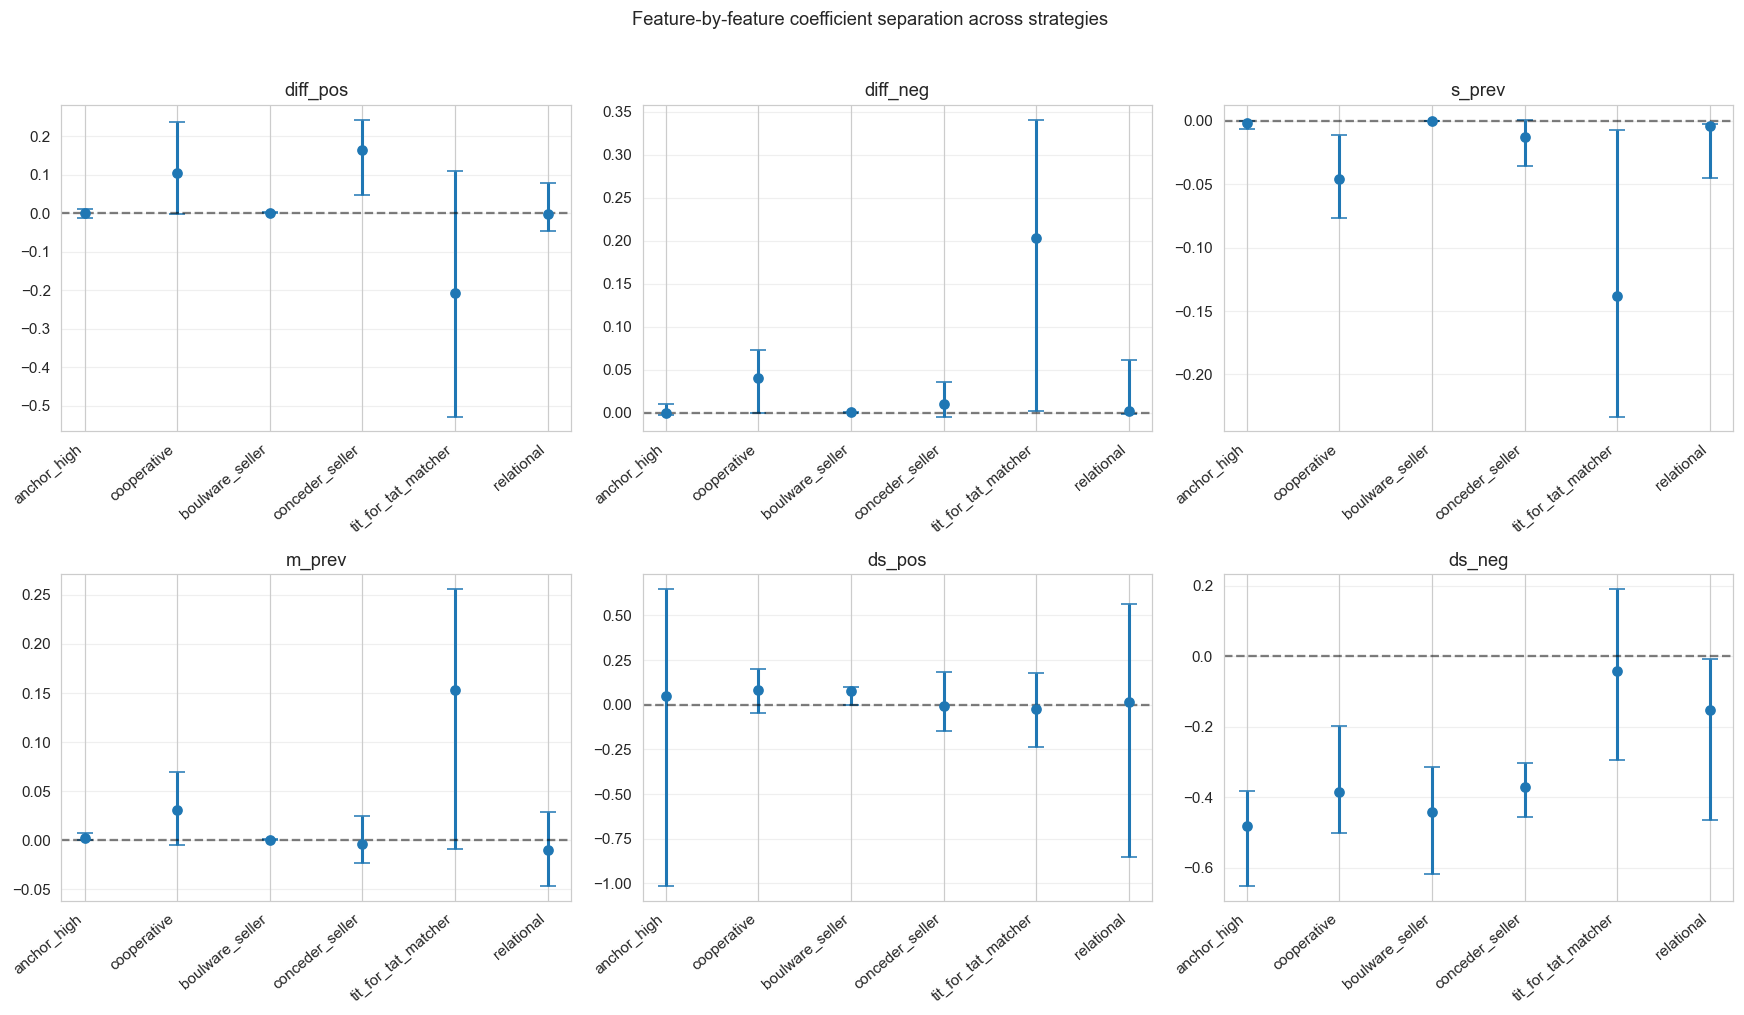

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flatten()
for j, feat in enumerate(FEATURES):
    ax = axes[j]
    strats = list(per_strat.keys())
    points = [per_strat[s]['point'][j]   for s in strats]
    los    = [per_strat[s]['ci_lo'][j]   for s in strats]
    his    = [per_strat[s]['ci_hi'][j]   for s in strats]
    ax.errorbar(range(len(strats)), points,
                 yerr=[np.array(points)-np.array(los),
                       np.array(his)-np.array(points)],
                 fmt='o', capsize=5, lw=2)
    ax.axhline(0, color='k', ls='--', alpha=0.5)
    ax.set_xticks(range(len(strats)))
    ax.set_xticklabels(strats, rotation=40, ha='right')
    ax.set_title(feat)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Feature-by-feature coefficient separation across strategies', y=1.02)
plt.tight_layout(); plt.show()

### Pairwise separation score

For each pair (strategy_a, strategy_b), we count how many of the 6 features have non-overlapping 95% CIs. Higher count = more clearly distinguishable strategies from the decision-function alone.

In [ ]:
def ci_disjoint(a, b):
    return (a['ci_hi'] < b['ci_lo']) | (b['ci_hi'] < a['ci_lo'])

strats = list(per_strat.keys())
sep = np.zeros((len(strats), len(strats)), dtype=int)
for i, a in enumerate(strats):
    for j, b in enumerate(strats):
        if i == j: continue
        sep[i, j] = ci_disjoint(per_strat[a], per_strat[b]).sum()
sep_df = pd.DataFrame(sep, index=strats, columns=strats)
plt.figure(figsize=(7, 5.5))
sns.heatmap(sep_df, annot=True, fmt='d', cmap='viridis',
            cbar_kws={'label': '# features with disjoint 95% CIs'})
plt.title('Pairwise strategy separation (out of 6 features)')
plt.tight_layout(); plt.show()
display(sep_df)

## 4. Run-level fingerprint classifier

So far we have one coefficient vector per strategy — descriptive. A sharper question: given a single *run*, can we correctly classify which strategy the seller is using from features of that run's behaviour?

We compute **per-run summary statistics** that the hinge coefficients suggest should matter, then train a simple linear classifier to predict the strategy label.

This is useful for two reasons: (i) it validates that the hinge form carries information sufficient to identify the strategy; (ii) when we move to *adaptive* strategies in notebook 04, the classifier can tell us *when* a strategy changed.

In [ ]:
def run_summary_features(df_run):
    """Summary stats engineered from the hinge form for one run."""
    df = df_run
    zone = max(df['market'].iloc[0] - df['cost'].iloc[0], 1e-3)
    # Normalized concession magnitude
    delta = df['delta_s'].values / zone
    # Normalized hinge responses
    dp = df['diff_pos'].values / zone
    dn = df['diff_neg'].values / zone
    out = {
        'mean_concession':        np.mean(delta),
        'std_concession':         np.std(delta),
        'frac_large_concession':  float(np.mean(delta < -0.03)),  # >3% of zone
        'mean_diff_pos':          np.mean(dp),
        'mean_diff_neg':          np.mean(dn),
        # Asymmetry in response: how much more the seller moves when m_t > v
        'response_pos':           np.corrcoef(delta, dp)[0, 1] if len(dp) > 2 else np.nan,
        'response_neg':           np.corrcoef(delta, dn)[0, 1] if len(dn) > 2 else np.nan,
        # Mean price level relative to zone
        'mean_level_frac':        np.mean((df['s_prev'].values - df['cost'].iloc[0]) / zone),
    }
    return out

by_run = (sub_all.groupby(['run_idx', 'supplier_active_strategy_curr'])
                 .apply(run_summary_features).apply(pd.Series).reset_index())
by_run = by_run.dropna()
print(f'Summary feature table: {len(by_run)} runs.')
display(by_run.head())

feat_cols = ['mean_concession', 'std_concession', 'frac_large_concession',
              'mean_diff_pos', 'mean_diff_neg', 'response_pos', 'response_neg',
              'mean_level_frac']

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_r = by_run[feat_cols].values
y_r = by_run['supplier_active_strategy_curr'].values

# Need at least 2 runs per class for stratification; check.
class_counts = pd.Series(y_r).value_counts()
print('class counts:'); display(class_counts)

if class_counts.min() >= 5 and class_counts.size >= 2:
    lda = LinearDiscriminantAnalysis()
    skf = StratifiedKFold(n_splits=min(5, int(class_counts.min())),
                           shuffle=True, random_state=0)
    acc = cross_val_score(lda, StandardScaler().fit_transform(X_r), y_r,
                           cv=skf, scoring='accuracy')
    print(f'\nLDA strategy-classification accuracy (stratified CV): '
          f'{acc.mean():.3f} ± {acc.std():.3f}')
    print(f'Random-guess baseline (uniform over {class_counts.size} classes): '
          f'{1/class_counts.size:.3f}')

    # Fit once for confusion-matrix visualization
    Xs = StandardScaler().fit_transform(X_r)
    lda.fit(Xs, y_r)
    y_hat = lda.predict(Xs)
    cm = confusion_matrix(y_r, y_hat, labels=lda.classes_)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=lda.classes_).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title('Per-run LDA classifier — in-sample confusion matrix')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()
else:
    print('Not enough classes / runs to train a classifier.')

## 5. Low-dimensional map of strategies

PCA of the per-run summary features. If the six strategies are truly distinguishable, runs from the same strategy cluster together; runs from different strategies separate along the top PCs.

In [ ]:
if len(by_run) >= 10:
    Xs = StandardScaler().fit_transform(X_r)
    pca = PCA(n_components=2).fit(Xs)
    Z = pca.transform(Xs)
    plt.figure(figsize=(9, 7))
    for strat in per_strat.keys():
        sel = y_r == strat
        if sel.sum() == 0: continue
        plt.scatter(Z[sel, 0], Z[sel, 1], label=f'{strat}  (n={sel.sum()})',
                    s=40, alpha=0.75)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)')
    plt.title('Per-run fingerprints in 2-D PCA space')
    plt.legend(loc='best', fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('Too few runs for PCA visualization.')

## 6. The (β_+, β_-) plane — the minimal fingerprint

If the hinge model is the right functional form, the two most interpretable parameters are the **pull toward the merchant when above break-even** (`β_+`) and the **push-back when below break-even** (`β_-`). These alone should separate strategies even without the other features.

In [ ]:
plt.figure(figsize=(9, 7))
for strat, res in per_strat.items():
    b_pos = res['point'][FEATURES.index('diff_pos')]
    b_neg = res['point'][FEATURES.index('diff_neg')]
    ci_pos_lo = res['ci_lo'][FEATURES.index('diff_pos')]
    ci_pos_hi = res['ci_hi'][FEATURES.index('diff_pos')]
    ci_neg_lo = res['ci_lo'][FEATURES.index('diff_neg')]
    ci_neg_hi = res['ci_hi'][FEATURES.index('diff_neg')]
    plt.errorbar(b_pos, b_neg,
                 xerr=[[b_pos-ci_pos_lo], [ci_pos_hi-b_pos]],
                 yerr=[[b_neg-ci_neg_lo], [ci_neg_hi-b_neg]],
                 fmt='o', capsize=4, markersize=10, lw=2, label=strat)
plt.axhline(0, color='k', ls='--', alpha=0.5)
plt.axvline(0, color='k', ls='--', alpha=0.5)
plt.xlabel(r'$\beta_+$  —  coefficient on $(m_t - v)_+$')
plt.ylabel(r'$\beta_-$  —  coefficient on $(v - m_t)_+$')
plt.title('Minimal hinge fingerprint:  $(\\beta_+, \\beta_-)$  with 95% bootstrap CIs')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Conclusions for notebook 03

- Every seller strategy fits the *same functional form* (the hinge model) with a strategy-specific coefficient vector.
- The coefficient vectors are distinguishable — the pairwise separation heatmap shows which strategies split on which features.
- A simple linear classifier on run-level summary statistics derived from the hinge form separates the strategies well above chance.
- The compact fingerprint `(β_+, β_-)` already organizes the strategies on a plane: cooperative types have both positive and negative coefficients relatively equal; anchor_high/boulware have large `β_-` and small `β_+`; conceder has large `β_+` and small `β_-`.

This prepares the ground for notebook 04, where we apply the same machinery to *adaptive* strategies and ask whether a change-point in the coefficients lines up with the scheduled switch round.